In [ ]:
pip install -U finance-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.9 MB/s eta 0:00:00


In [ ]:
import FinanceDataReader as fdr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def get_close(ticker, start, end=None):
    """
    종가 데이터 수집 (Get Close Prices)
    """
    return fdr.DataReader(ticker, start, end)['Close']

def calc_daily_return(prices):
    """
    일별 수익률 계산 (Calculate Daily Returns)
    """
    return prices.pct_change().fillna(0)

def calc_cum_return(prices):
    """
    누적 수익률(자산 흐름) 계산 (Calculate Cumulative Returns)
    """
    return prices / prices.iloc[0]

def calc_portfolio(prices, weight=None):
    """
    포트폴리오 수익률 계산 (Calculate Portfolio Returns)
    returns: (일별 수익률, 누적 수익률)
    """
    # 1. 누적 수익률 계산
    cum_ret = calc_cum_return(prices)

    # 2. 비중 설정 (기본값: 동일 비중)
    if not weight:
        weight = [1/len(prices.columns)] * len(prices.columns)

    # 3. 포트폴리오 누적 수익률 (가중 평균)
    # 각 자산의 누적 수익률에 비중을 곱해 합산합니다. (Buy & Hold 가정)
    port_cum_ret = (cum_ret * weight).sum(axis=1)

    # 4. 포트폴리오 일별 수익률 (역산)
    port_daily_ret = port_cum_ret.pct_change().fillna(0)

    return port_daily_ret, port_cum_ret


def evaluate_performance(cum_ret, daily_ret, risk_free_rate=0.02):
    """
    성과 지표 평가 (CAGR, MDD, Volatility, Sharpe ratio)
    """

    # 1. 수익성 (CAGR)
    total_ret = cum_ret.iloc[-1]
    years = len(cum_ret) / 252
    cagr = total_ret ** (1 / years) - 1

    # 2. 안정성 (MDD)
    historical_max = cum_ret.cummax()
    dd = (cum_ret - historical_max) / historical_max * 100
    mdd = dd.min()

    # 3. 위험 (변동성)
    daily_vol = daily_ret.std()               # 일일 변동성
    annual_vol = daily_vol * np.sqrt(252)     # 연간 변동성

    # 4. 효율 (Sharpe Ratio)
    annual_return = daily_ret.mean() * 252    # 연간 수익률 (산술 평균)
    sharpe_ratio = (annual_return - risk_free_rate) / annual_vol # 위험 한 단위당 수익

    print(f"▶ 최종 수익률   : {(cum_ret.iloc[-1]-1)*100:.2f}%")
    print(f"=== 성과 평가 리포트 ===")
    print(f"1. 수익성 (CAGR) : {cagr*100:.2f}%")
    print(f"2. 안정성 (MDD)  : {mdd:.2f}%")
    print(f"-" * 30)
    print(f"3. 연간 변동성   : {annual_vol*100:.2f}%")
    print(f"4. 샤프 지수     : {sharpe_ratio:.4f}")

    return cagr, dd, mdd

In [ ]:
# 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,201 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and direc

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 폰트 경로 지정 (NanumBarunGothic)
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

# 폰트 파일이 존재하는지 확인하고 추가
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumBarunGothic')
else:
    print("폰트 파일을 찾을 수 없습니다. 설치가 제대로 되었는지 확인해주세요.")

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

## 리밸런싱


#### 리밸런싱 개념  

"지금까지 다룬 **'바이 앤 홀드(Buy & Hold)'** 전략은 자산 가치의 장기적 우상향을 전제로, 시장의 단기 변동성을 인내하며 자본 차익을 극대화하는 방식이었습니다. 그러나 이 전략은 시장 급락기(Drawdown)에 포트폴리오의 손실을 방어할 수단이 부재하다는 구조적 한계를 가집니다.

이를 보완하기 위해 우리는 **'리밸런싱(Rebalancing)'** 기법을 도입합니다. 리밸런싱이란 시간 경과에 따라 변동된 자산 비중을 주기적으로 초기 목표 비중으로 환원시키는 과정을 뜻합니다.

이 과정의 본질은 **'평균 회귀(Mean Reversion)의 원리'** 를 활용하는 것입니다. 가격이 상승하여 비중이 비대해진 자산(고평가)을 일부 매도하여 차익을 확정하고, 상대적으로 가격이 하락하여 비중이 축소된 자산(저평가)을 저가에 매수하는 것입니다. 즉, 리밸런싱은 단순한 정리가 아니라, **'변동성 수확(Volatility Harvesting)'을 통해 고점 매도와 저점 매수를 시스템적으로 반복 수행**하는 고도화된 투자 기술입니다."

### 리밸런싱 예시: "폭락장에서의 수량 확보"

주가가 반토막이 났다가 원점으로 돌아오는 상황을 가정해 봅시다.

1. **상황 설정:**
* **초기 자산:** 200만 원 (주식 100만 : 현금 100만) = **1:1 비중**
* **주가:** 1주당 1만 원 (100주 보유)


2. **이벤트 발생 (폭락장):**
* 주가가 50% 폭락하여 **50만 원**이 되었습니다.
* **Buy & Hold:** 주식 50만 + 현금 100만 = 총 150만 원 (평가손실 -25%)
* **리밸런싱:** 총자산 150만 원의 비율을 다시 1:1로 맞춥니다.
* 주식 목표: 75만 원 / 현금 목표: 75만 원
* **행동:** 현금 25만 원으로 **주식(1주당 5천원)을 50주 더 삽니다.** (이제 총 150주 보유)


3. **상황 종료 (주가 원점 회복):**
* 주가가 다시 **1만 원**으로 복구되었습니다.

---

### 결과 비교

| 구분 | Buy & Hold  | 리밸런싱 |
| --- | --- | --- |
| **보유 주식 수** | 1주 (그대로) | **150주 (늘어남)** |
| **최종 주식 평가** | 100만원 | 150만원 |
| **최종 현금** | 100만원 | 75만원 |
| **총 자산** | **200만 원 (본전)** | **225만 원 (+12.5% 수익)** |

> **핵심 원리:**
> 주식 가격은 제자리로 돌아왔을 뿐이지만, 리밸런싱을 한 사람은 **폭락장에서 '주식 수량'을 늘려놨기 때문에** 상승분을 1.5배로 누리게 된 것입니다. 이것이 **"하락장을 기회로 만드는"** 리밸런싱의 진짜 위력입니다.




              Stock_Price  Buy_Hold  Rebalancing
시작(Start)             100   20000.0      20000.0
폭락(Crash)              50   15000.0      15000.0
회복(Recovery)          100   20000.0      22500.0


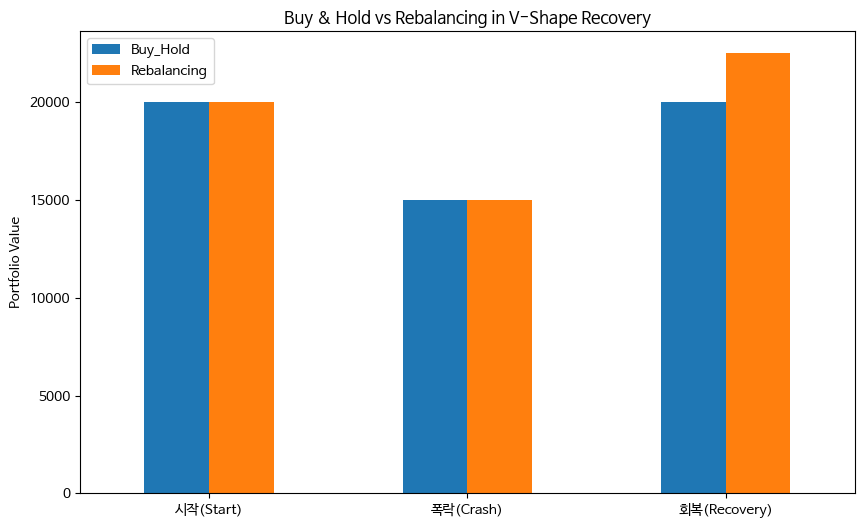

In [ ]:
# 1. 가상의 시나리오 데이터 생성 (V자 반등)
# 주식: 100 -> 50 (반토막) -> 100 (회복)
# 현금: 가격 변동 없음 (1.0 유지)
data = pd.DataFrame(
    {
        'Stock_Price': [100, 50, 100],
        'Cash_Price':  [1, 1, 1]
    },
    index=['시작(Start)', '폭락(Crash)', '회복(Recovery)']
)

# 2. 투자 시뮬레이션
results = []
initial_budget = 20000 # 2만원 시작

# [Case A] Buy & Hold (각 1만원씩 매수 후 방치)
stock_shares_bh = 10000 / data['Stock_Price'].iloc[0] # 100주
cash_amount_bh = 10000 # 현금 만원

data['Buy_Hold'] = (data['Stock_Price'] * stock_shares_bh) + cash_amount_bh

# [Case B] Rebalancing (폭락 시점에 5:5 비율 조절)
# (1) 시작
stock_shares_rb = 10000 / data['Stock_Price'].iloc[0] # 100주
cash_amount_rb = 10000

# (2) 폭락 시점 자산 평가 및 리밸런싱
val_stock_crash = 50 * stock_shares_rb # 5000원
val_cash_crash = 10000
total_crash = val_stock_crash + val_cash_crash # 15000원

# 리밸런싱: 15000원을 5:5로 나눔 -> 각 7500원
target_amount = total_crash / 2 # 7500원
# 현금 2500원으로 주식 추가 매수 (주가 50원)
shares_to_buy = (val_cash_crash - target_amount) / 50 # 50주 추가 매수
stock_shares_rb += shares_to_buy # 150주 보유!
cash_amount_rb = target_amount # 현금 7500원 남음

# (3) 회복 시점 평가
final_val_stock = 100 * stock_shares_rb # 150주 * 100원 = 15000원
final_val_cash = cash_amount_rb
final_total_rb = final_val_stock + final_val_cash # 22500원

# 데이터프레임에 결과 입력 (단순화를 위해 중간 과정 생략하고 결과만 매핑)
data['Rebalancing'] = [20000, 15000, final_total_rb]

# 3. 결과 출력 및 시각화
print(data[['Stock_Price', 'Buy_Hold', 'Rebalancing']])

# 폰트 설정을 다시 적용 (만약 이전 셀에서 설정이 제대로 안되었을 경우를 대비)
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic') # 폰트 설정 변경
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

data[['Buy_Hold', 'Rebalancing']].plot(kind='bar', figsize=(10, 6), rot=0)
plt.title("Buy & Hold vs Rebalancing in V-Shape Recovery")
plt.ylabel("Portfolio Value")
plt.show()

**매월 말 주식:현금 = 1:1 비율로 조절해주는 리밸런싱 기법**을 도입해보겠습니다.    

#### 리밸런싱 기법을 코드로 구현하기

In [ ]:
# 더미데이터
close_data = pd.DataFrame(
    {
        "kodex200": [100, 140, 120, 110, 100, 120, 110, 115, 120],
        "kodex10Bond": [100, 90, 105, 115, 125, 130, 120, 125, 130],
    },
    index=pd.to_datetime(["2025-01-31", "2025-02-10", "2025-02-21", "2025-02-28", "2025-03-10", "2025-03-19", "2025-03-31", "2025-04-20", "2025-04-30",])
)
close_data

,kodex200,kodex10Bond
2025-01-31,100,100
2025-02-10,140,90
2025-02-21,120,105
2025-02-28,110,115
2025-03-10,100,125
2025-03-19,120,130
2025-03-31,110,120
2025-04-20,115,125
2025-04-30,120,130


리밸런싱 날짜 계산

In [ ]:
# 매달 마지막 영업일

copyclose_data = close_data.copy()

copyclose_data['year'] = copyclose_data.index.year
copyclose_data['month'] = copyclose_data.index.month

copyclose_data

,kodex200,kodex10Bond,year,month
2025-01-31,100,100,2025,1
2025-02-10,140,90,2025,2
2025-02-21,120,105,2025,2
2025-02-28,110,115,2025,2
2025-03-10,100,125,2025,3
2025-03-19,120,130,2025,3
2025-03-31,110,120,2025,3
2025-04-20,115,125,2025,4
2025-04-30,120,130,2025,4


In [ ]:
rebalancingDate = copyclose_data.drop_duplicates(['year','month'], keep="last").index
rebalancingDate

DatetimeIndex(['2025-01-31', '2025-02-28', '2025-03-31', '2025-04-30'], dtype='datetime64[ns]', freq=None)

리밸런싱 비중 계산

In [ ]:
# 원하는 비중으로 넣어도 되지만, 우선 동일비중으로 가정
defaultWeight = [1/len(close_data.columns)] * len(close_data.columns) # [1/n, 1/n ~~~]
defaultWeight

[0.5, 0.5]

In [ ]:
monthlyWeight = pd.DataFrame([defaultWeight] * len(rebalancingDate), index=rebalancingDate, columns=close_data.columns)  # df 변환
monthlyWeight

,kodex200,kodex10Bond
2025-01-31,0.5,0.5
2025-02-28,0.5,0.5
2025-03-31,0.5,0.5
2025-04-30,0.5,0.5


**(월별 리밸런싱 비중 * 누적 수익률) 구하기**

In [ ]:
start = rebalancingDate[0] # 리밸런싱 날짜, 초기값 첫 투자일

for end in rebalancingDate[1:]:
    weight = monthlyWeight.loc[start] # 당월 리밸런싱 비율
    priceData = close_data.loc[start:end] # 당월 가격 데이터
    cumReturn = calc_cum_return(priceData) # 당월 누적 수익률
    weightedCumReturn = weight * cumReturn # 당월 리밸런싱 비율이 반영된 누적 수익률

    start = end # start 갱신
    print(weightedCumReturn)

            kodex200  kodex10Bond
2025-01-31      0.50        0.500
2025-02-10      0.70        0.450
2025-02-21      0.60        0.525
2025-02-28      0.55        0.575
            kodex200  kodex10Bond
2025-02-28  0.500000     0.500000
2025-03-10  0.454545     0.543478
2025-03-19  0.545455     0.565217
2025-03-31  0.500000     0.521739
            kodex200  kodex10Bond
2025-03-31  0.500000     0.500000
2025-04-20  0.522727     0.520833
2025-04-30  0.545455     0.541667


**월별 투자 결과가 그 다음달에도 연속적으로 반영되어야 합니다.**

In [ ]:
# 투자 결과 연속 반영

totalAsset = 1 # 총 자산, 초기값 1
start = rebalancingDate[0] # 리밸런싱 날짜, 초기값 첫 투자일

for end in rebalancingDate[1:]:
    weight = monthlyWeight.loc[start] # 당월 리밸런싱 비율
    priceData = close_data.loc[start:end] # 당월 가격 데이터
    cumReturn = calc_cum_return(priceData) # 당월 누적 수익률
    weightedCumReturn = weight * cumReturn # 당월 리밸런싱 비율이 반영된 누적 수익률


    netCumReturn = totalAsset * weightedCumReturn # 전월 투자 결과 반영


    start = end # start 갱신

    print("갱신 전 총 자산: ",totalAsset)
    totalAsset = netCumReturn.iloc[-1].sum() # 총 자산 갱신
    print(netCumReturn)
    print("갱신 후 총 자산: ",totalAsset)

갱신 전 총 자산:  1
            kodex200  kodex10Bond
2025-01-31      0.50        0.500
2025-02-10      0.70        0.450
2025-02-21      0.60        0.525
2025-02-28      0.55        0.575
갱신 후 총 자산:  1.125
갱신 전 총 자산:  1.125
            kodex200  kodex10Bond
2025-02-28  0.562500     0.562500
2025-03-10  0.511364     0.611413
2025-03-19  0.613636     0.635870
2025-03-31  0.562500     0.586957
갱신 후 총 자산:  1.1494565217391304
갱신 전 총 자산:  1.1494565217391304
            kodex200  kodex10Bond
2025-03-31  0.574728     0.574728
2025-04-20  0.600852     0.598675
2025-04-30  0.626976     0.622622
갱신 후 총 자산:  1.2495985671936758


**위 결과를 하나의 데이터 프레임으로 합쳐서 전체 포트폴리오의 누적 수익률을 계산 할 수 있습니다.**

In [ ]:
# 하나의 데이터 프레임으로 합치기

portfolio = pd.DataFrame() # 빈 데이터 프레임 생성

totalAsset = 1 # 총 자산, 초기값 1
start = rebalancingDate[0] # 리밸런싱 날짜, 초기값 첫 투자일

for end in rebalancingDate[1:]:
    weight = monthlyWeight.loc[start] # 당월 리밸런싱 비율
    priceData = close_data.loc[start:end] # 당월 가격 데이터
    cumReturn = calc_cum_return(priceData) # 당월 누적 수익률
    weightedCumReturn = weight * cumReturn # 당월 리밸런싱 비율이 반영된 누적 수익률
    netCumReturn = totalAsset * weightedCumReturn # 전월 투자 결과 반영


    start = end # start 갱신
    totalAsset = netCumReturn.iloc[-1].sum() # 총 자산 갱신
    portfolio = pd.concat([portfolio, netCumReturn]) # 매월 데이터 추가

portfolio

,kodex200,kodex10Bond
2025-01-31,0.500000,0.500000
2025-02-10,0.700000,0.450000
2025-02-21,0.600000,0.525000
2025-02-28,0.550000,0.575000
2025-02-28,0.562500,0.562500
2025-03-10,0.511364,0.611413
2025-03-19,0.613636,0.635870
2025-03-31,0.562500,0.586957
2025-03-31,0.574728,0.574728
2025-04-20,0.600852,0.598675


**매달 중복되는 데이터를 제거하고, 최종 포트폴리오 누적 수익률을 계산합니다.**

In [ ]:
portfolio.index.duplicated(keep='last')

array([False, False, False,  True, False, False, False,  True, False,
       False, False])

In [ ]:
portfolio.loc[~portfolio.index.duplicated(keep='last')]

,kodex200,kodex10Bond
2025-01-31,0.500000,0.500000
2025-02-10,0.700000,0.450000
2025-02-21,0.600000,0.525000
2025-02-28,0.562500,0.562500
2025-03-10,0.511364,0.611413
2025-03-19,0.613636,0.635870
2025-03-31,0.574728,0.574728
2025-04-20,0.600852,0.598675
2025-04-30,0.626976,0.622622


In [ ]:
portfolio = portfolio.loc[~portfolio.index.duplicated(keep='last')]

In [ ]:
portCumReturn = portfolio.sum(axis=1)
portCumReturn

,0
2025-01-31,1.000000
2025-02-10,1.150000
2025-02-21,1.125000
2025-02-28,1.125000
2025-03-10,1.122777
2025-03-19,1.249506
2025-03-31,1.149457
2025-04-20,1.199528
2025-04-30,1.249599


#### 리밸런싱 일자 조회, 리밸런싱 포트폴리오 결과 계산 함수화

In [62]:
def getRebalancingDate(close_data, period="month"):
    """
    리밸런싱 일자 추출
    월별, 분기별, 연별
    """
    data = close_data.copy()
    data = pd.DataFrame(data) # 시리즈형 데이터가 들어오더라도 리밸런싱 날짜를 계산하기 위해서는 dataframe으로 변환 해야 함
    data.index = pd.to_datetime(data.index)
    data['year'] = data.index.year
    data['month'] = data.index.month

    # 월말 리밸런싱
    if period == "month":
        rebalancingDate = data.drop_duplicates(['year', 'month'], keep="last").index

    # 분기말 리밸런싱
    if period == "quarter":
        # 3 6 9 12월 말에 리밸런싱
        # np where 같은걸로 3, 6, 9, 12월 데이터만 가져오고
        # drop_duplicates keep last
        quarter = [3,6,9,12]
        data = data.loc[data['month'].isin(quarter)]
        rebalancingDate = data.drop_duplicates(['year', 'month'], keep="last").index

    # 연말 리밸런싱
    if period == "year":
        rebalancingDate = data.drop_duplicates(['year'], keep="last").index

    return rebalancingDate

In [63]:
def getRebalancingPortfolioResult(close_data, period = "month", weightDf=None):
    """
    리밸런싱 포트폴리오 결과
    close_data: 종가 데이터
    weight: 포트폴리오 개별자산 비중
    return: 포트폴리오 일간수익률, 누적수익률
    """

    # 자산별 비중. 기본값: 동일비중
    if weightDf is None:
        rebalancingDate = getRebalancingDate(close_data, period) # 리밸런싱 날짜
        weightDf = pd.DataFrame([[1/len(close_data.columns)] * len(close_data.columns)] * len(rebalancingDate),
                              index=rebalancingDate,
                              columns=close_data.columns)
    # 자산별 비중이 있는 경우
    else:
        close_data = close_data.loc[weightDf.index[0]:]
        rebalancingDate = getRebalancingDate(close_data, period) # 리밸런싱 날짜

    portfolio = pd.DataFrame() # 빈 데이터 프레임 생성

    totalAsset = 1 # 총 자산, 초기값 1
    start = rebalancingDate[0] # 리밸런싱 날짜, 초기값 첫 투자일

    for end in rebalancingDate[1:]:
        weight = weightDf.loc[start] # 당월 리밸런싱 비율
        priceData = close_data.loc[start:end] # 당월 가격 데이터
        cumReturn = calc_cum_return(priceData) # 당월 누적 수익률
        weightedCumReturn = weight * cumReturn # 당월 리밸런싱 비율이 반영된 누적 수익률
        netCumReturn = totalAsset * weightedCumReturn # 전월 투자 결과 반영

        start = end # start 갱신
        totalAsset = netCumReturn.iloc[-1].sum() # 총 자산 갱신
        portfolio = pd.concat([portfolio, netCumReturn]) # 매월 데이터 추가

    portfolio = portfolio.loc[~portfolio.index.duplicated(keep='last')] # 중복 데이터 제거
    portfolioCumulativeReturn = portfolio.sum(axis=1) # 포트폴리오 누적 수익률
    portfolioDayReturn = (portfolioCumulativeReturn / portfolioCumulativeReturn.shift(1)).fillna(1) - 1# 포트폴리오 일간 수익률

    return portfolioDayReturn, portfolioCumulativeReturn

#### 실전 데이터 적용

In [64]:
# 데이터 로드
stockETF = get_close("069500", "2024", "2025-12-31") # 주식 ETF
bondETF = get_close("152380", "2024", "2025-12-31") # 채권 ETF

# kodex200 = 069500
# kodex10Bond = 152380
# S&P500 = SPY
# 미국 7-10 국채 = IEF

sb_close_data = pd.concat([stockETF, bondETF], axis=1)
sb_close_data.columns = ['stockETF', 'bondETF']
sb_close_data.dropna(inplace=True)
sb_close_data

,stockETF,bondETF
Date,,
2024-01-02,34802,65291
2024-01-03,33837,65158
2024-01-04,33540,65445
2024-01-05,33445,65009
2024-01-08,33335,65069
...,...,...
2025-12-23,58595,67635
2025-12-24,58610,67883
2025-12-26,59110,67710


In [65]:
rebalancingDate = getRebalancingDate(sb_close_data, 'month')
rebalancingDate

DatetimeIndex(['2024-01-31', '2024-02-29', '2024-03-29', '2024-04-30',
               '2024-05-31', '2024-06-28', '2024-07-31', '2024-08-30',
               '2024-09-30', '2024-10-31', '2024-11-29', '2024-12-30',
               '2025-01-31', '2025-02-28', '2025-03-31', '2025-04-30',
               '2025-05-30', '2025-06-30', '2025-07-31', '2025-08-29',
               '2025-09-30', '2025-10-31', '2025-11-28', '2025-12-30'],
              dtype='datetime64[ns]', name='Date', freq=None)

리밸런싱 포트폴리오 결과 계산

In [66]:
# weightDf를 전달하지 않으면 동일 비중 리밸런싱
weightDf = pd.DataFrame([[0.5, 0.5]] * len(rebalancingDate),
                              index=rebalancingDate,
                              columns=sb_close_data.columns)
weightDf

,stockETF,bondETF
Date,,
2024-01-31,0.5,0.5
2024-02-29,0.5,0.5
2024-03-29,0.5,0.5
2024-04-30,0.5,0.5
2024-05-31,0.5,0.5
2024-06-28,0.5,0.5
2024-07-31,0.5,0.5
2024-08-30,0.5,0.5
2024-09-30,0.5,0.5


In [67]:
# 리밸런싱 날짜 계산 (실전 데이터 적용을 위해 다시 계산)
rebalancingDate = getRebalancingDate(sb_close_data)

# weightDf 생성 (주식 5 : 채권 5)
weightDf = pd.DataFrame([[0.5, 0.5]] * len(rebalancingDate),
                              index=rebalancingDate,
                              columns=sb_close_data.columns)

# weightDf를 전달하지 않으면 동일 비중 리밸런싱
# period='year'를 명시하여 연별 리밸런싱 수행
rebalPortfolioDayReturn, rebalPortfolioCumulativeReturn = getRebalancingPortfolioResult(sb_close_data, period='month', weightDf=weightDf)

주식 채권 1:1 B&H 전략 결과 계산

In [68]:
#포트폴리오 계산
port_day_ret, port_cum_ret= calc_portfolio(sb_close_data.loc[rebalancingDate[0]:])
print(port_day_ret,port_cum_ret)

Date
2024-01-31    0.000000
2024-02-01    0.008959
2024-02-02    0.019009
2024-02-05   -0.009925
2024-02-06   -0.002608
                ...   
2025-12-23    0.001847
2025-12-24    0.001500
2025-12-26    0.004482
2025-12-29    0.018183
2025-12-30    0.001405
Length: 465, dtype: float64 Date
2024-01-31    1.000000
2024-02-01    1.008959
2024-02-02    1.028138
2024-02-05    1.017934
2024-02-06    1.015279
                ...   
2025-12-23    1.421329
2025-12-24    1.423461
2025-12-26    1.429840
2025-12-29    1.455839
2025-12-30    1.457885
Length: 465, dtype: float64


주식 100% B&H 전략 결과 계산

In [69]:
stockDayReturn = calc_daily_return(stockETF.loc[rebalancingDate[0]:])
stockCumReturn = calc_cum_return(stockETF.loc[rebalancingDate[0]:])
print(port_day_ret,port_cum_ret)

Date
2024-01-31    0.000000
2024-02-01    0.008959
2024-02-02    0.019009
2024-02-05   -0.009925
2024-02-06   -0.002608
                ...   
2025-12-23    0.001847
2025-12-24    0.001500
2025-12-26    0.004482
2025-12-29    0.018183
2025-12-30    0.001405
Length: 465, dtype: float64 Date
2024-01-31    1.000000
2024-02-01    1.008959
2024-02-02    1.028138
2024-02-05    1.017934
2024-02-06    1.015279
                ...   
2025-12-23    1.421329
2025-12-24    1.423461
2025-12-26    1.429840
2025-12-29    1.455839
2025-12-30    1.457885
Length: 465, dtype: float64


#### 전략 성과 비교

In [70]:
print("리밸런싱 포트폴리오 누적 수익률")
rebalCagr, rebalDD, rebalMDD = evaluate_performance(rebalPortfolioCumulativeReturn,rebalPortfolioDayReturn)

리밸런싱 포트폴리오 누적 수익률
▶ 최종 수익률   : 41.69%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 20.78%
2. 안정성 (MDD)  : -9.45%
------------------------------
3. 연간 변동성   : 11.14%
4. 샤프 지수     : 1.5717


In [71]:
print("Buy & Hold 포트폴리오 누적 수익률")
cagr, dd, mdd = evaluate_performance(port_cum_ret,port_day_ret)

Buy & Hold 포트폴리오 누적 수익률
▶ 최종 수익률   : 45.79%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 22.67%
2. 안정성 (MDD)  : -9.73%
------------------------------
3. 연간 변동성   : 11.93%
4. 샤프 지수     : 1.6052


In [72]:
print("주식 100% 포트폴리오 누적 수익률")
print(stockCumReturn.iloc[-1])
stockCagr, stockDd, stockMdd = evaluate_performance(stockCumReturn,stockDayReturn)

주식 100% 포트폴리오 누적 수익률
1.8768685467714594
▶ 최종 수익률   : 87.69%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 40.66%
2. 안정성 (MDD)  : -21.61%
------------------------------
3. 연간 변동성   : 21.87%
4. 샤프 지수     : 1.5794


In [73]:
# 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [74]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 폰트 경로 지정 (NanumBarunGothic)
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

# 폰트 파일이 존재하는지 확인하고 추가
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumBarunGothic')
else:
    print("폰트 파일을 찾을 수 없습니다. 설치가 제대로 되었는지 확인해주세요.")

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

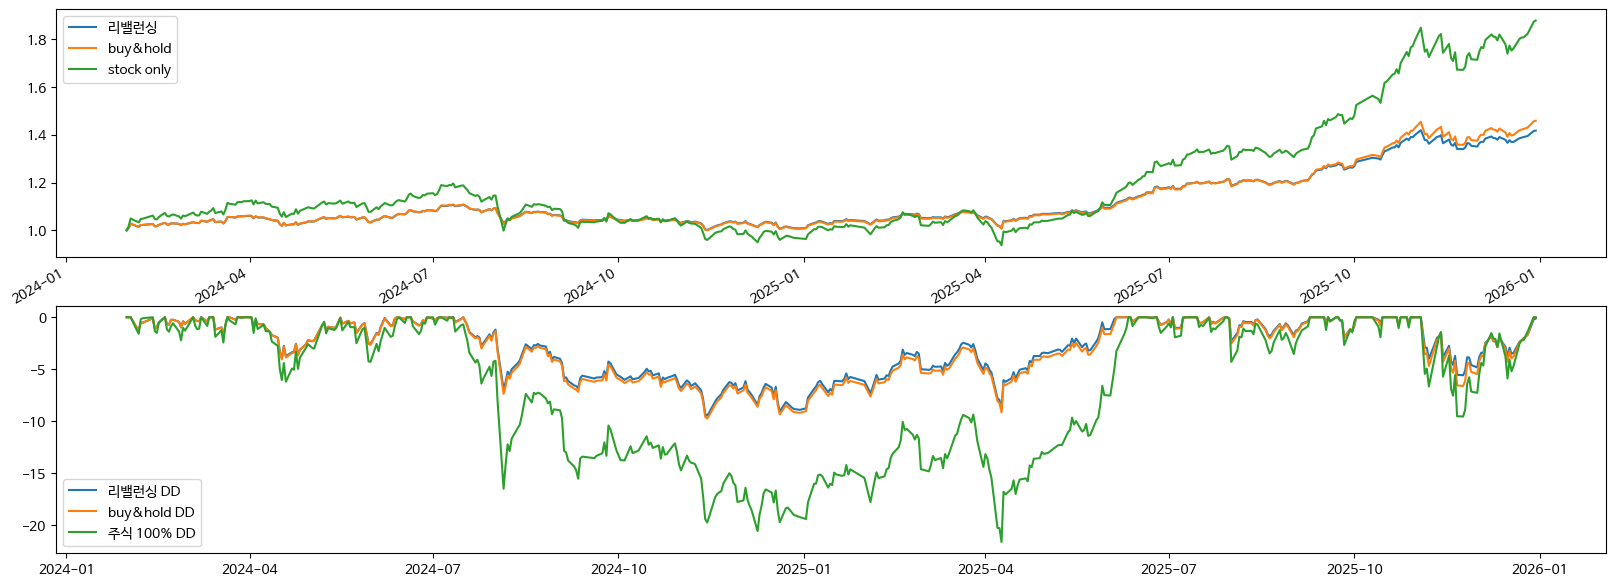

In [75]:
plt.rc('font', family='NanumBarunGothic') # 폰트 설정 변경
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(20,8))

# 수익곡선
plt.subplot(2,1,1)
rebalPortfolioCumulativeReturn.plot(label="리밸런싱")
port_cum_ret.plot(label="buy&hold")
stockCumReturn.plot(label="stock only")
plt.legend()

# dd 곡선
plt.subplot(2,1,2)
plt.plot(rebalDD, label="리밸런싱 DD")
plt.plot(dd, label="buy&hold DD")
plt.plot(stockDd, label="주식 100% DD")
plt.legend()

plt.show()

In [76]:
# 데이터 로드
samsung = get_close("005930", "2024", "2025-12-31") # 삼성전자
naver = get_close("035420", "2024", "2025-12-31") # NAVER

sn_close_data = pd.concat([samsung, naver], axis=1)
sn_close_data.columns = ['samsung', 'naver']
sn_close_data.dropna(inplace=True)
sn_close_data

,samsung,naver
Date,,
2024-01-02,79600,227500
2024-01-03,77000,222000
2024-01-04,76600,223000
2024-01-05,76600,220500
2024-01-08,76500,226500
...,...,...
2025-12-23,111500,237000
2025-12-24,111100,236500
2025-12-26,117000,231500


In [77]:
sn_day_ret, sn_cum_ret = calc_portfolio(sn_close_data.loc[rebalancingDate[0]:])
sncagr,sndd,snmdd = evaluate_performance(sn_cum_ret, sn_day_ret)

▶ 최종 수익률   : 42.94%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 21.36%
2. 안정성 (MDD)  : -25.10%
------------------------------
3. 연간 변동성   : 28.66%
4. 샤프 지수     : 0.7484


In [78]:
rb_day_ret, rb_cum_ret = getRebalancingPortfolioResult(sn_close_data)
rbcagr,rbdd,rbmdd = evaluate_performance(rb_cum_ret, rb_day_ret)

▶ 최종 수익률   : 50.00%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 24.58%
2. 안정성 (MDD)  : -24.33%
------------------------------
3. 연간 변동성   : 28.14%
4. 샤프 지수     : 0.8501


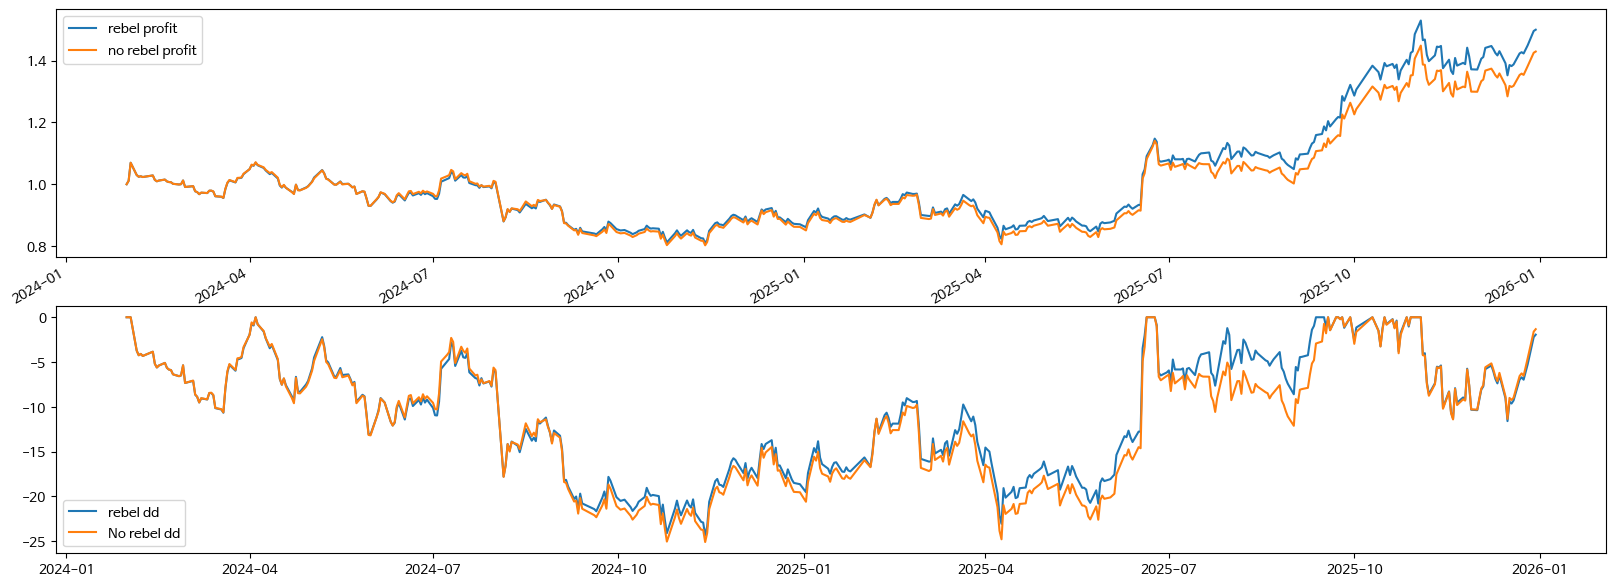

In [79]:
plt.figure(figsize=(20,8))
# 수익곡선
plt.subplot(2,1,1)
rb_cum_ret.plot(label="rebel profit")
sn_cum_ret.plot(label="no rebel profit")
plt.legend()

# dd 곡선
plt.subplot(2,1,2)
plt.plot(rbdd, label="rebel dd")
plt.plot(sndd, label="No rebel dd")
plt.legend()

plt.show()

# Another function

In [ ]:
import pandas as pd
import numpy as np

def get_rebalancing_dates(close_data, period="month"):
    """
    리밸런싱 날짜 추출 (Pandas Grouper 활용)
    - 입력: 종가 데이터, 주기('month', 'quarter', 'year')
    - 출력: 리밸런싱 시행일(DatetimeIndex)
    """
    # 주기별 Pandas Frequency 문자열 매핑
    freq_map = {'month': 'ME', 'quarter': 'QE', 'year': 'YE'} # Pandas 2.x 기준 (구버전은 'M', 'Q', 'Y')

    # 1. 예외처리: 잘못된 주기 입력
    if period not in freq_map:
        raise ValueError("period must be 'month', 'quarter', or 'year'")

    freq = freq_map[period]

    # Grouper를 이용해 주기별 마지막 영업일 추출
    # resample은 달력 기준 마지막 날을 뱉지만, groupby().tail(1)은 실제 데이터가 있는 마지막 날을 반환함
    rebalancing_dates = close_data.groupby(pd.Grouper(freq=freq)).apply(lambda x: x.index[-1])

    return rebalancing_dates.sort_index()

In [ ]:
def cal_rebalancing_portfolio(close_data, period="month", weight_df=None, enable_plot=True):
    """
    리밸런싱 포트폴리오 성과 계산 (Chunk 방식)
    """
    # 1. 리밸런싱 날짜 구하기
    rebal_dates = get_rebalancing_dates(close_data, period)

    # 2. 초기 비중 설정 (없으면 동일 비중 1/N)
    if weight_df is None:
        n_assets = len(close_data.columns)
        weight_df = pd.DataFrame(
            index=rebal_dates,
            columns=close_data.columns,
            data=1/n_assets
        )

    # 3. 데이터 범위 보정 (비중 설정일 이후 데이터만 사용)
    first_date = weight_df.index[0]
    sub_data = close_data.loc[first_date:]

    # 4. 전체 기간 일별 수익률 미리 계산 (벡터화)
    daily_rets = sub_data.pct_change().fillna(0)

    portfolio_chunks = [] # 기간별 결과를 담을 리스트
    total_value = 1.0     # 초기 자산 (1.0 = 100%)

    # 5. 리밸런싱 기간별 순회 (Loop)
    full_dates = list(rebal_dates)
    if full_dates[-1] != sub_data.index[-1]:
        full_dates.append(sub_data.index[-1])

    for start, end in zip(full_dates[:-1], full_dates[1:]):

        current_weights = weight_df.loc[start]
        chunk_rets = daily_rets.loc[start:end].iloc[1:]

        if chunk_rets.empty: continue
        cum_growth = (1 + chunk_rets).cumprod()
        chunk_value = (cum_growth * current_weights).sum(axis=1) * total_value
        portfolio_chunks.append(chunk_value)
        total_value = chunk_value.iloc[-1]

    # 6. 결과 병합
    if not portfolio_chunks:
        return None, None

    portfolio_cum_ret = pd.concat(portfolio_chunks)
    portfolio_cum_ret.loc[first_date] = 1.0
    portfolio_cum_ret = portfolio_cum_ret.sort_index()

    # 일별 수익률 역산
    portfolio_day_ret = portfolio_cum_ret.pct_change().fillna(0)

    if enable_plot:
      # 결과 계산 (MDD 등)
      historical_max = portfolio_cum_ret.cummax()
      dd = (portfolio_cum_ret - historical_max) / historical_max * 100
      mdd = dd.min()

      tickers = close_data.columns.tolist() # 티커 리스트 추출
      daily_rets = close_data.pct_change().fillna(0) # 개별 종목 수익률 (배경 그리기용)

      # 시각화 함수 호출
      plot_portfolio_result(tickers, daily_rets, portfolio_cum_ret, dd, mdd)

    return portfolio_day_ret, portfolio_cum_ret



def plot_portfolio_result(tickers, daily_rets, port_cum_ret, dd, mdd):
    """
    포트폴리오 성과 시각화 함수
    - port_cum_ret : 포트폴리오 누적 수익률 (Series)
    - daily_rets   : 개별 자산 일별 수익률 (DataFrame) - 배경에 개별 종목 흐름 그리기용
    - dd           : 낙폭 데이터 (Series)
    - mdd          : 최대 낙폭 값 (float)
    - tickers      : 종목 코드 리스트 (list)
    """

    plt.figure(figsize=(8, 5))

    # [차트 1] 포트폴리오 누적 수익률 (Asset Growth)
    plt.subplot(2, 1, 1)

    # 1. 메인 포트폴리오 선 그리기
    plt.plot(port_cum_ret.index, port_cum_ret, label='Portfolio', color='#d62728', linewidth=1.5)

    # 2. 개별 종목 흐름 얇게 그리기 (비교용)
    # daily_rets가 있을 때만 그립니다.
    if daily_rets is not None and tickers is not None:
        for t in tickers:
            if t in daily_rets.columns:
                ind_cum = (1 + daily_rets[t]).cumprod()
                # 시작점을 포트폴리오와 맞추거나 1.0으로 통일
                # 여기선 데이터 자체의 흐름을 보기 위해 1.0 기준 계산값 사용
                plt.plot(ind_cum.index, ind_cum, label=f'{t}', alpha=0.3, linewidth=0.8, linestyle='--')

    plt.axhline(1.0, color='gray', linestyle=':', alpha=0.5) # 본전 라인
    plt.title('Portfolio Cumulative Return', fontsize=14, fontweight='bold')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)


    # [차트 2] 낙폭 (Drawdown)
    plt.subplot(2, 1, 2)

    plt.fill_between(dd.index, dd, 0, color='#1f77b4', alpha=0.3) # 파란색 채우기
    plt.plot(dd.index, dd, color='#1f77b4', linewidth=0.5)       # 파란 실선

    plt.title('Portfolio Drawdown (MDD)', fontsize=12)
    plt.axhline(mdd, color='red', linestyle='--', label=f'Max DD: {mdd:.2f}%') # MDD 선

    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.ylabel('Drawdown (%)')

    plt.tight_layout()
    plt.show()

In [ ]:
# 데이터 로드
samsung = get_close("005930", "2024", "2025-12-31") # 삼성전자
naver = get_close("035420", "2024", "2025-12-31") # NAVER

sn_close_data = pd.concat([samsung, naver], axis=1)
sn_close_data.columns = ['samsung', 'naver']
sn_close_data.dropna(inplace=True)
sn_close_data

,samsung,naver
Date,,
2024-01-02,79600,227500
2024-01-03,77000,222000
2024-01-04,76600,223000
2024-01-05,76600,220500
2024-01-08,76500,226500
...,...,...
2025-12-23,111500,237000
2025-12-24,111100,236500
2025-12-26,117000,231500


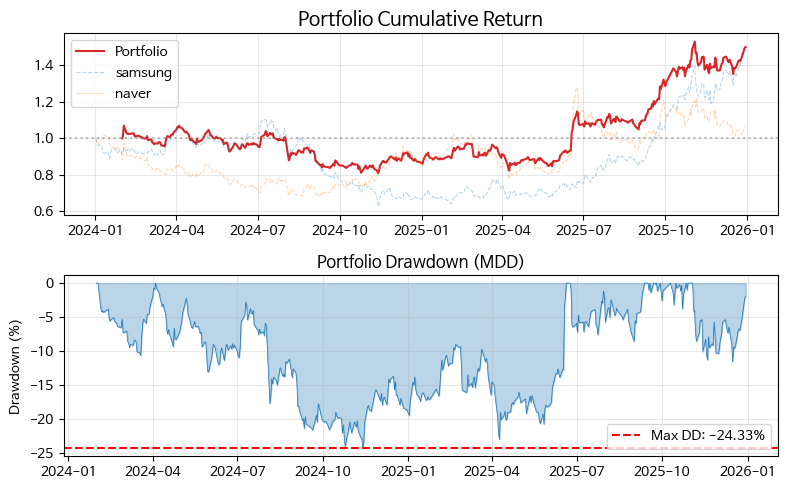

In [ ]:
# 월간 리밸런싱, 동일 비중
rb_day_ret, rb_cum_ret = cal_rebalancing_portfolio(sn_close_data , period="month")


In [ ]:
_ = evaluate_performance(rb_cum_ret, rb_day_ret)

▶ 최종 수익률   : 50.00%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 24.58%
2. 안정성 (MDD)  : -24.33%
------------------------------
3. 연간 변동성   : 28.14%
4. 샤프 지수     : 0.8501
